# Left-NPC replication (SI)

Repeats the preferred-numerosity analysis (model 3, ground-truth fits, voxels with cvR² > 0) in left NPC alongside right NPC: distributions of μ per range, and the correspondence of subject-mean μ between NPCl and NPCr.

In [30]:
import numpy as np
from pathlib import Path

import pandas as pd
import seaborn as sns

In [31]:
bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth_r = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
# pars_estimates_r = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-responses_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars_ground_truth_l = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCl_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth_r, pars_ground_truth_l], keys=['NPCr', 'NPCl'], names=['roi'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.unique(level='smoothed')

pars = pars.xs(3, level='model_label')


pars = pars[pars[('cvr2', 'nan')] > 0.0]

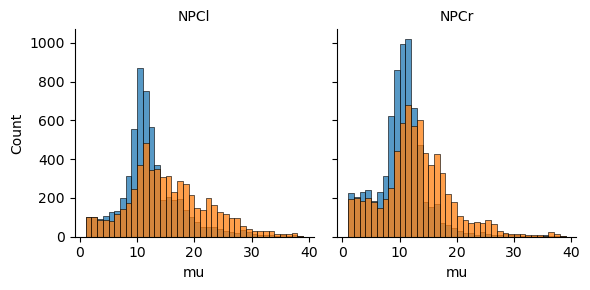

In [33]:
tmp = pd.concat((pars[('mu','narrow')], pars[('mu','wide')]), axis=1, keys=['narrow', 'wide'])

tmp.columns.name = 'range'


g = sns.FacetGrid(tmp.stack().to_frame('mu').reset_index(), col='roi', hue='range', col_order=['NPCl', 'NPCr'])

g.map_dataframe(sns.histplot, x='mu', bins=np.arange(1, 40))

g.set_titles(col_template='{col_name}')


,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,roi,1,38,19.511791,0.00008,0.07877,1.0


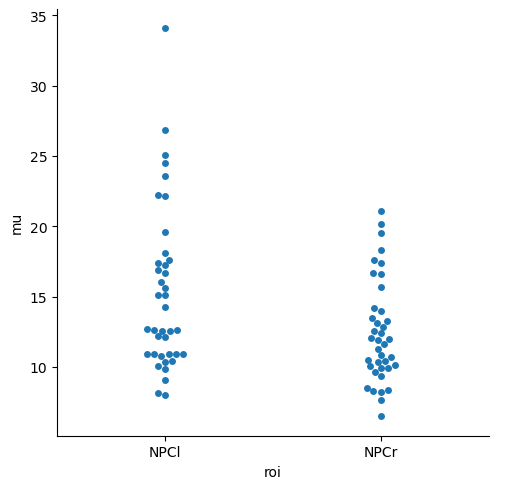

In [46]:
import pingouin as pg
tmp = pars.groupby(['subject', 'roi']).mean()[('mu', 'narrow')].to_frame('mu')

sns.catplot(data=tmp.reset_index(), x='roi', y='mu', kind='swarm')

pg.rm_anova(data=tmp.reset_index(), dv='mu', within='roi', subject='subject')

<Axes: xlabel='NPCl', ylabel='NPCr'>

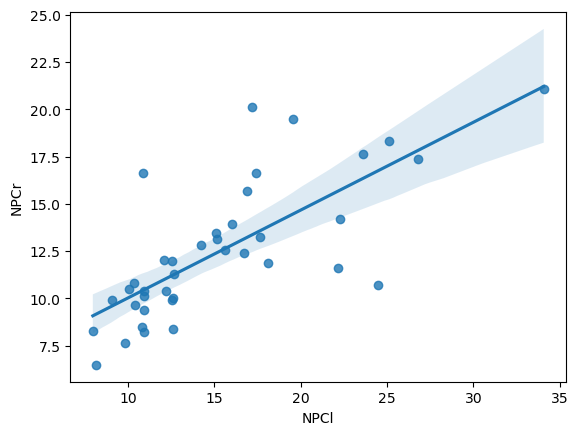

In [52]:
sns.regplot(data=tmp.unstack('roi').droplevel(0, axis=1), x='NPCl', y='NPCr')